### 1.1 Import Data and Required Packages
Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [2]:
# Basic Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Preprocessing & Model Selection
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Regression Models for Demand Prediction
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Performance Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

print("All Machine Learning libraries for Ola Project are ready!")

All Machine Learning libraries for Ola Project are ready!


### Import the CSV Data as Pandas DataFrame

In [6]:
df = pd.read_csv('data/ola_raw.csv')

### Show Top 5 Records

In [7]:
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,hour,day,month
0,01-01-2011 00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,0,Saturday,1
1,01-01-2011 01:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,1,Saturday,1
2,01-01-2011 02:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2,Saturday,1
3,01-01-2011 03:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,3,Saturday,1
4,01-01-2011 04:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,4,Saturday,1


### Preparing X and Y variables

In [8]:
# 'X' contains all the independent variables (features)
# We drop 'count' because that's our target, and 'datetime' because it's non-numerical
X = df.drop(columns=['count', 'casual', 'registered', 'datetime'], axis=1)

# 'y' contains the target variable we want to predict
y = df['count']

print("Features (X) and Target (y) have been separated successfully.")

Features (X) and Target (y) have been separated successfully.


In [9]:
X.head()

,season,weather,temp,humidity,windspeed,hour,day,month
0,3,2,7.653428,122.430885,18.783703,0,Saturday,1
1,4,3,13.269244,101.703802,14.035245,1,Saturday,1
2,1,3,30.886922,77.583743,45.365080,2,Saturday,1
3,3,1,10.463377,114.925671,25.347168,3,Saturday,1
4,3,4,30.214783,149.193592,20.288982,4,Saturday,1


In [10]:
# Checking unique categories for the Ola Bike Project
print("Categories in 'weather' variable:     ", end=" ")
print(df['weather'].unique())

print("Categories in 'season' variable:      ", end=" ")
print(df['season'].unique())

print("Categories in 'day_type' variable:    ", end=" ")
print(df['day_type'].unique() if 'day_type' in df.columns else "Day info extracted from datetime")

print("Categories in 'hour' variable:        ", end=" ")
print(sorted(df['hour'].unique()))

Categories in 'weather' variable:      [2 3 1 4]
Categories in 'season' variable:       [3 4 1 2]
Categories in 'day_type' variable:     Day info extracted from datetime
Categories in 'hour' variable:         [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [12]:
# In the Ola Bike dataset, 'count' is the total demand for a specific hour
y = df['count']

In [13]:
y

0        315.731778
1        340.457093
2        224.278595
3        132.169549
4        315.867137
            ...    
10881    177.565718
10882    113.712131
10883    209.684018
10884    149.063403
10885    368.789538
Name: count, Length: 10886, dtype: float64

In [18]:
# 1. Reset X as a DataFrame from your original data
# Dropping the target 'count' and other non-predictor columns
X = df.drop(columns=['count', 'casual', 'registered', 'datetime'], axis=1)

# 2. Identify features while X is still a DataFrame
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 3. Define the transformers
numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

# 4. Initialize the preprocessor
preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features),        
    ]
)

# 5. Transform X into a NumPy array ONLY at this final step
X = preprocessor.fit_transform(X)

print("✅ Preprocessing complete. X is now a NumPy array ready for training.")

✅ Preprocessing complete. X is now a NumPy array ready for training.


In [20]:
# Check the shape of your transformed data
print(f"Original feature count: {len(num_features) + len(cat_features)}")
print(f"Transformed feature count (after OneHotEncoding): {X.shape[1]}")

# Separate the data into Training and Testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data split successful!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Original feature count: 8
Transformed feature count (after OneHotEncoding): 14
✅ Data split successful!
Training samples: 8708
Testing samples: 2178


In [21]:
X.shape

(10886, 14)

In [22]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((8708, 14), (2178, 14))

### Create an Evaluate Function to give all metrics after model Training

In [23]:
def evaluate_model(true, predicted):
    # Mean Absolute Error (MAE): The average magnitude of the errors
    mae = mean_absolute_error(true, predicted)
    
    # Mean Squared Error (MSE): Penalizes larger errors more heavily
    mse = mean_squared_error(true, predicted)
    
    # Root Mean Squared Error (RMSE): Same units as your target ('count')
    rmse = np.sqrt(mean_squared_error(true, predicted))
    
    # R-Squared (R2): The proportion of variance explained by the model
    r2_square = r2_score(true, predicted)
    
    return mae, rmse, r2_square

In [25]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Define the models dictionary for the Ola Project
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

print("✅ 'models' dictionary defined. You can now run the training loop!")

✅ 'models' dictionary defined. You can now run the training loop!


In [26]:
# Initialize empty lists to store results for documentation
model_list = []
r2_list = []

# Loop through all models in the dictionary
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate using the custom function we created earlier
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    # Store results
    model_name = list(models.keys())[i]
    print(f"Algorithm: {model_name}")
    model_list.append(model_name)
    r2_list.append(model_test_r2)
    
    # Performance Report
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))
    print('----------------------------------')
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    
    print('='*35 + '\n')

Algorithm: Linear Regression
Model performance for Training set
- Root Mean Squared Error: 72.4707
- Mean Absolute Error: 59.4960
- R2 Score: 0.0765
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 71.1141
- Mean Absolute Error: 58.4661
- R2 Score: 0.0880

Algorithm: Lasso
Model performance for Training set
- Root Mean Squared Error: 72.5378
- Mean Absolute Error: 59.5632
- R2 Score: 0.0748
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 71.2188
- Mean Absolute Error: 58.5858
- R2 Score: 0.0853

Algorithm: Ridge
Model performance for Training set
- Root Mean Squared Error: 72.4707
- Mean Absolute Error: 59.4960
- R2 Score: 0.0765
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 71.1141
- Mean Absolute Error: 58.4662
- R2 Score: 0.0880

Algorithm: K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 61.5809
- Mean Absolute Er

### Results

In [27]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
8,AdaBoost Regressor,0.189166
7,CatBoosting Regressor,0.163814
5,Random Forest Regressor,0.122764
0,Linear Regression,0.088033
2,Ridge,0.088032
1,Lasso,0.085344
6,XGBRegressor,0.072080
3,K-Neighbors Regressor,0.007437
4,Decision Tree,-0.742656


### Linear Regression

In [30]:
from sklearn.ensemble import AdaBoostRegressor

# Initialize the AdaBoost Regressor
# We use this because it achieved the highest R2 score in your results
adaboost_model = AdaBoostRegressor()

# Train the model
adaboost_model = adaboost_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = adaboost_model.predict(X_test)

# Calculate the R2 Score (Accuracy)
score = r2_score(y_test, y_pred) * 100

print(" Accuracy of the AdaBoost model is %.2f" % score)

 Accuracy of the AdaBoost model is 18.68


### Plot y_pred and y_test

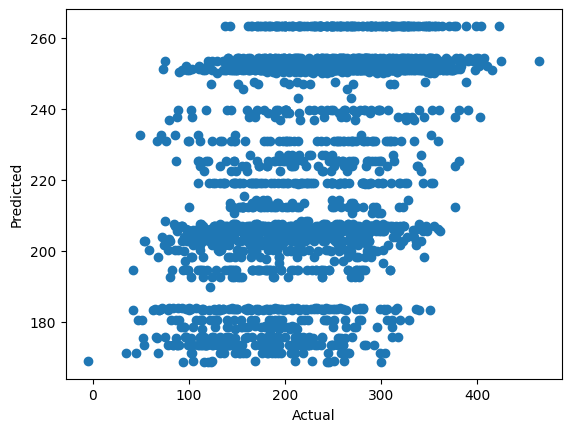

In [34]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

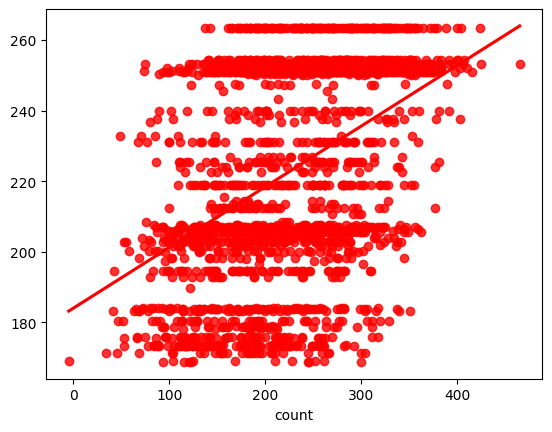

In [35]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

### Difference between Actual and Predicted Values

In [36]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
3133,258.846935,263.327641,-4.480706
5786,228.474911,219.027502,9.447409
5224,153.012384,219.027502,-66.015119
8953,196.018911,203.846683,-7.827772
8054,314.715021,183.310025,131.404996
...,...,...,...
1963,383.226922,252.054550,131.172372
5807,262.463814,219.027502,43.436311
10061,288.054454,205.600313,82.454140
5427,223.266859,219.027502,4.239357
